# Titanic Dataset — Exploratory Data Analysis (EDA)

This notebook performs a thorough EDA on the Titanic training dataset. It includes:

- Data loading & quick look
- Data cleaning & missing value analysis
- Univariate analysis (numerical & categorical)
- Bivariate analysis focusing on `Survived`
- Correlation analysis & heatmap
- Feature engineering suggestions and visualizations

Dataset path: `train.csv`



In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Display settings
%matplotlib inline
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

In [2]:
# Load dataset
df = pd.read_csv(r"train.csv")
print('Dataset shape:', df.shape)
df.head().style.set_caption('First 5 rows of the dataset')

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,nan,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,nan,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,nan,S


In [3]:
# Basic info and summary statistics
display(df.info())
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [4]:
# Missing values analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
miss_df = pd.concat([missing, missing_percent], axis=1)
miss_df.columns = ['missing_count', 'missing_percent']
display(miss_df)

,missing_count,missing_percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


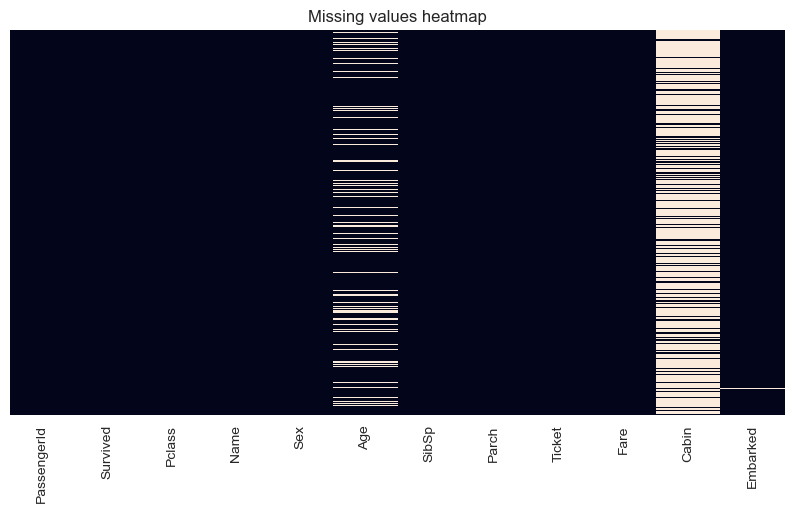

In [5]:
# Visualize missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing values heatmap')
plt.show()

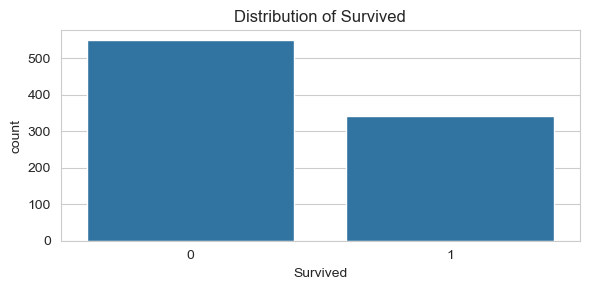

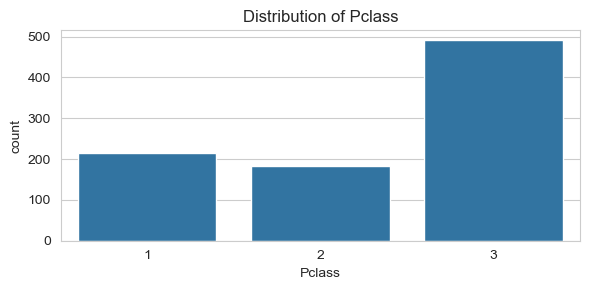

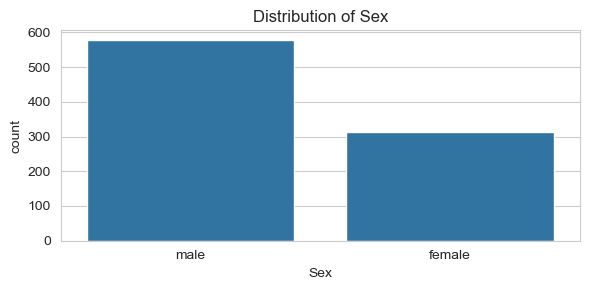

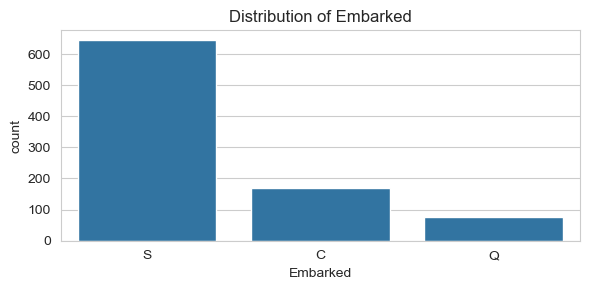

In [6]:
# Categorical variable distributions
categorical_cols = ['Survived','Pclass','Sex','Embarked']
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

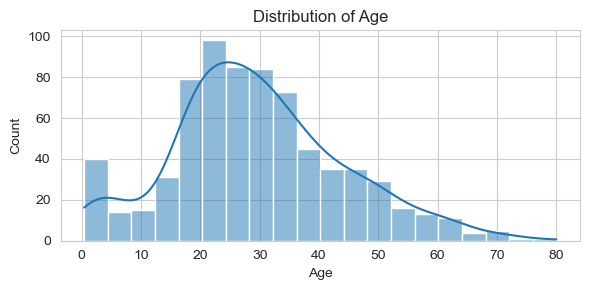

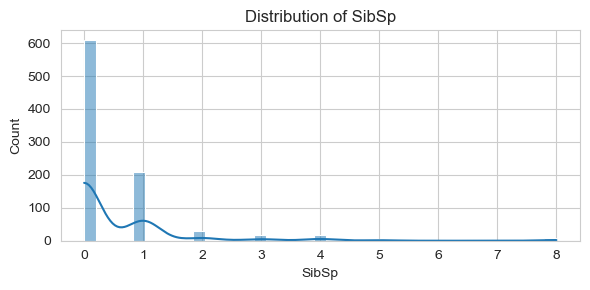

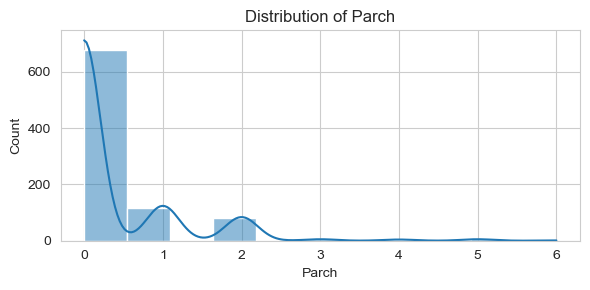

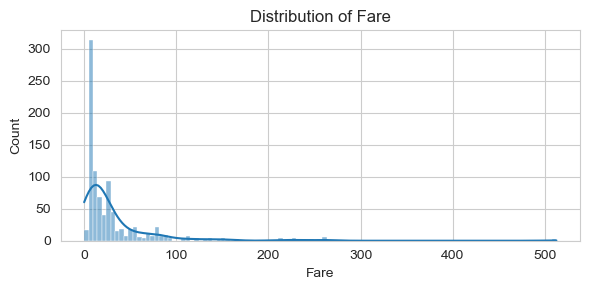

In [7]:
# Numerical distributions
num_cols = ['Age','SibSp','Parch','Fare']
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


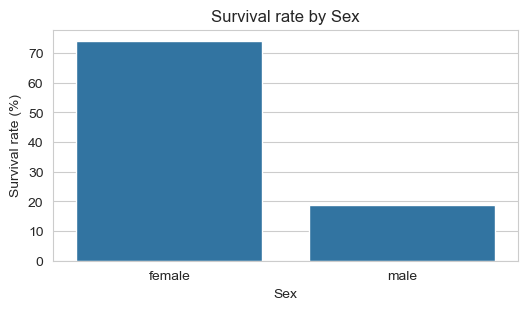

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


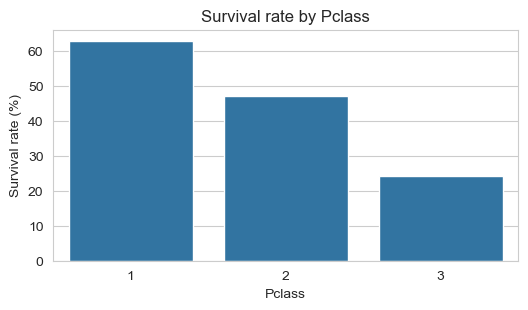

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


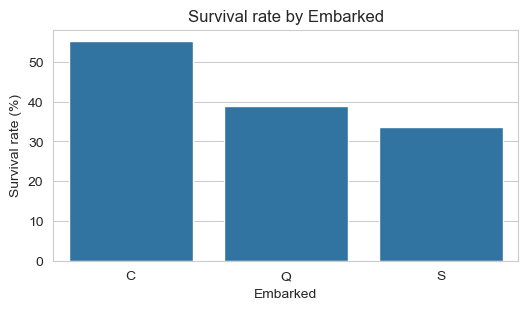

In [8]:
# Survival rates by Sex, Pclass, Embarked
for col in ['Sex','Pclass','Embarked']:
    ct = pd.crosstab(df[col], df['Survived'], normalize='index') * 100
    display(ct.style.set_caption(f'Survival rate by {col} (percent)'))
    plt.figure(figsize=(6,3))
    sns.barplot(x=ct.index, y=ct[1])
    plt.ylabel('Survival rate (%)')
    plt.title(f'Survival rate by {col}')
    plt.show()

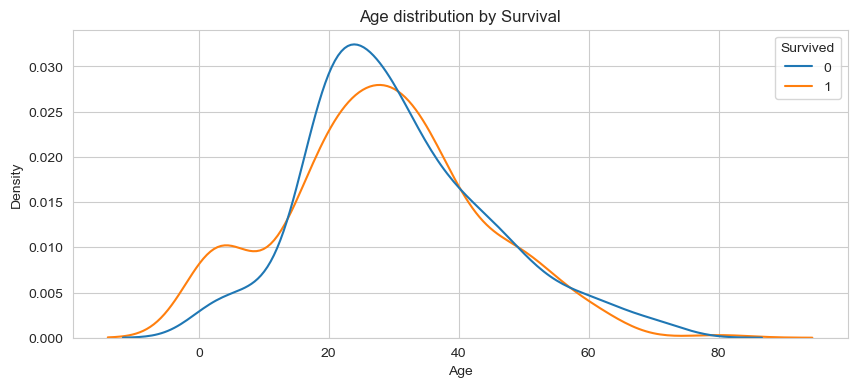

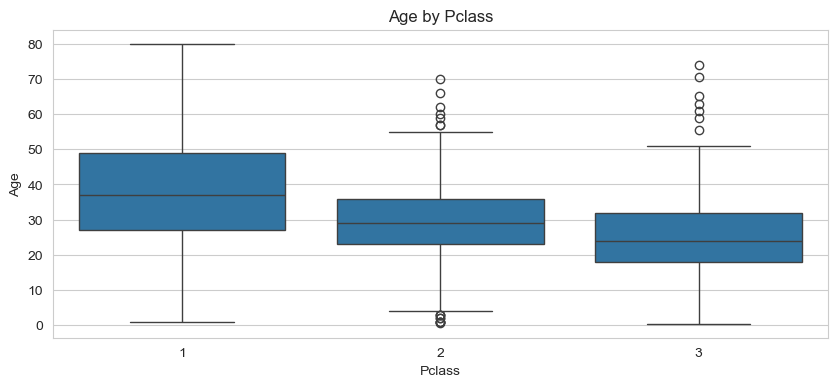

In [9]:
# Age distributions by Survived and Pclass
plt.figure(figsize=(10,4))
sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False)
plt.title('Age distribution by Survival')
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title('Age by Pclass')
plt.show()

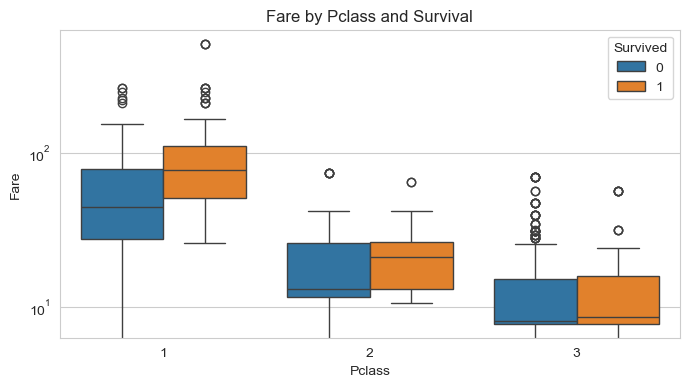

In [10]:
# Fare by Pclass and Survival
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived')
plt.title('Fare by Pclass and Survival')
plt.yscale('log')  # log scale to handle skewness
plt.show()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


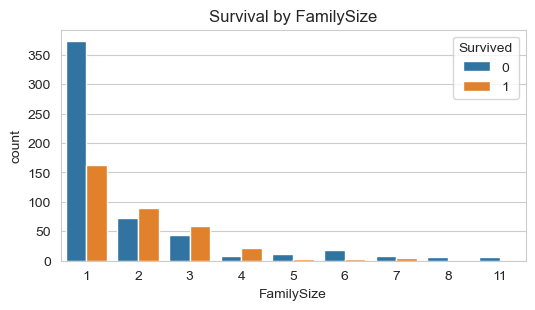

In [11]:
# Feature engineering: FamilySize from SibSp and Parch
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
display(df[['SibSp','Parch','FamilySize']].head())

plt.figure(figsize=(6,3))
sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.title('Survival by FamilySize')
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gatti\AppData\Local\Temp\ipykernel_22864\4074171953.py:2: SyntaxWarning: invalid escape sequence '\s'
  df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)


Survived,0,1
Title,,
Master,42.500000,57.500000
Miss,30.219780,69.780220
Mr,84.332689,15.667311
Mrs,20.800000,79.200000
Rare,55.555556,44.444444


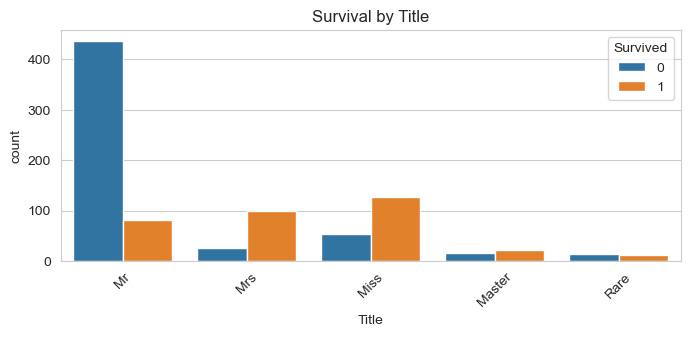

In [12]:
# Extract title from Name (Mr, Mrs, Miss, etc.) and analyze survival
df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)
# Group rare titles
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index.tolist()
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
display(pd.crosstab(df['Title'], df['Survived'], normalize='index')*100)
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='Title', hue='Survived')
plt.xticks(rotation=45)
plt.title('Survival by Title')
plt.show()

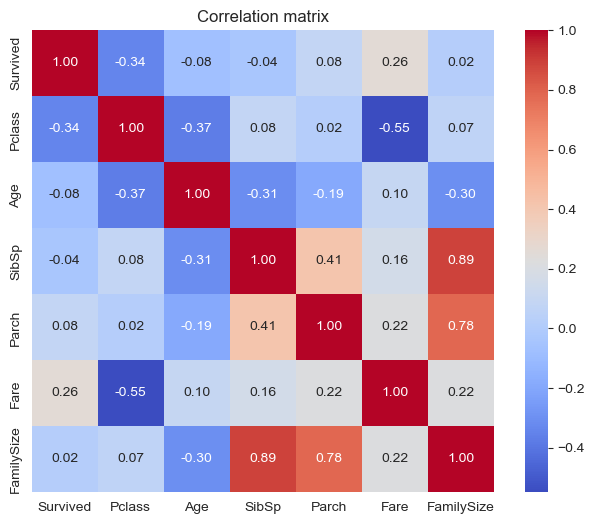

In [13]:
# Correlation matrix (numerical features)
num_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']].copy()
corr = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation matrix')
plt.show()

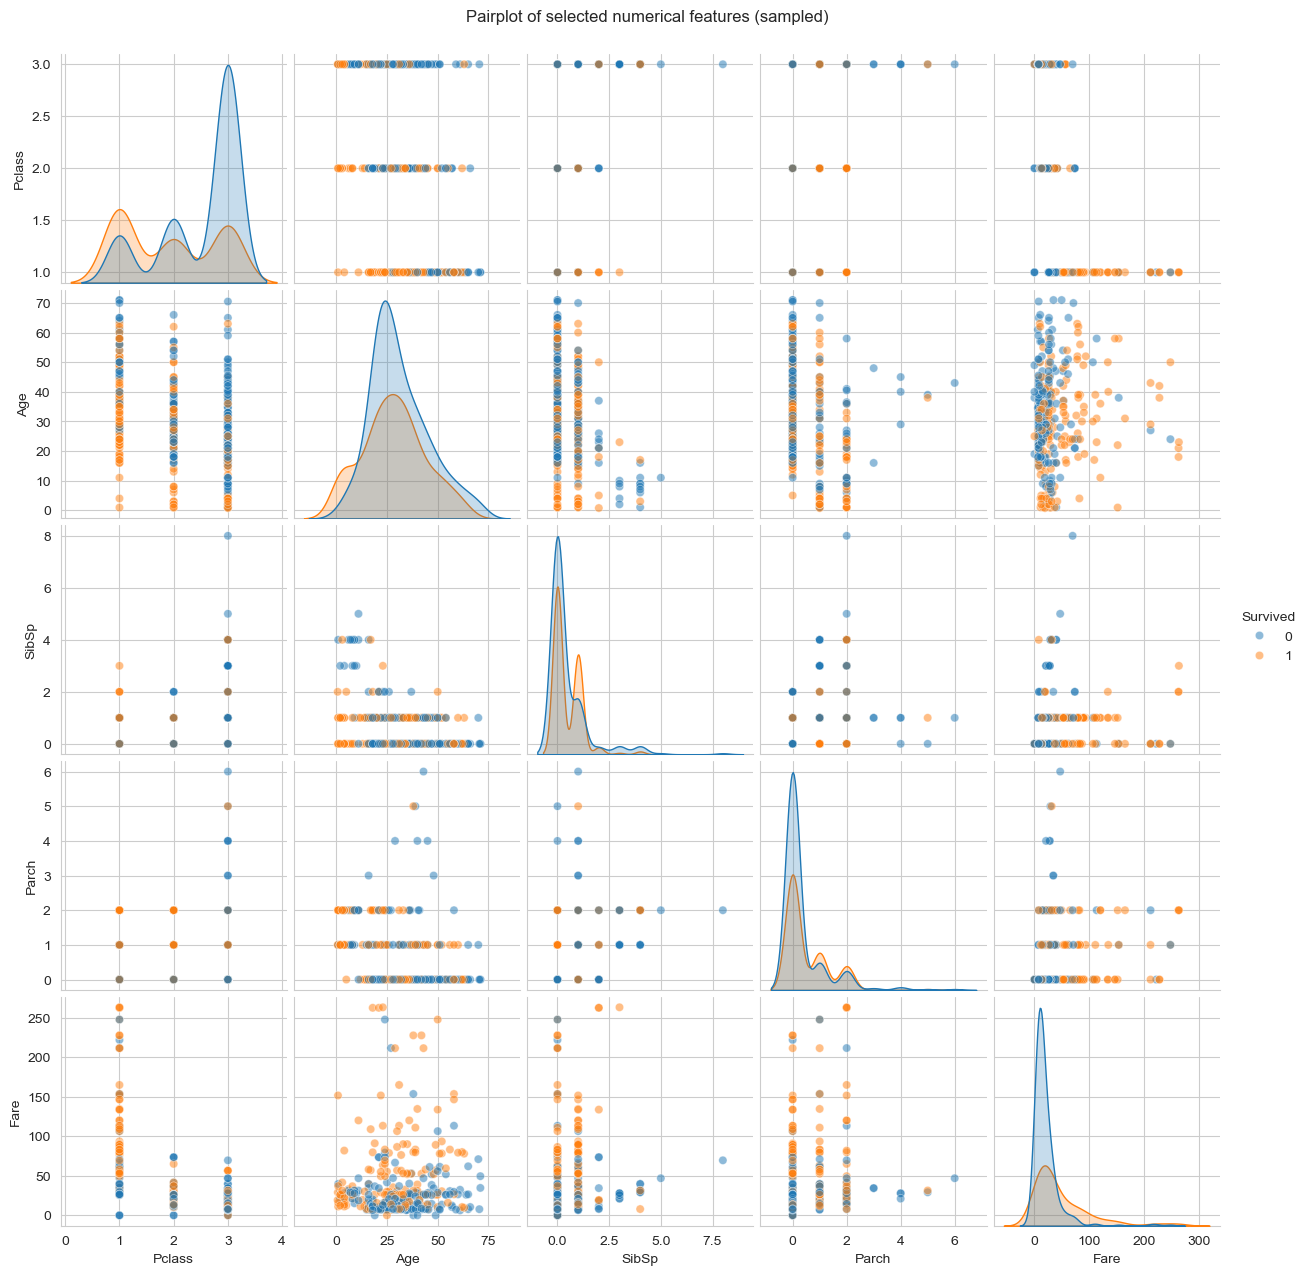

In [14]:
# Pairplot (sample for speed)
sample = df.sample(500, random_state=42) if df.shape[0] > 500 else df.copy()
sns.pairplot(sample[['Survived','Pclass','Age','SibSp','Parch','Fare']], hue='Survived', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of selected numerical features (sampled)', y=1.02)
plt.show()

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

C:\Users\gatti\AppData\Local\Temp\ipykernel_22864\35216349.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


Filled missing Embarked with mode


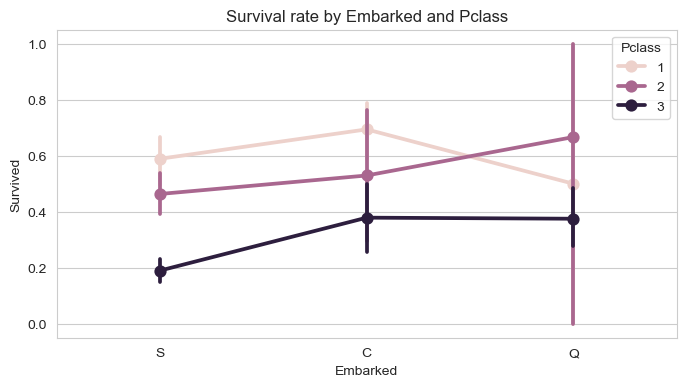

In [15]:
# Embarked: examine missing
display(df['Embarked'].value_counts(dropna=False))

# Fill missing Embarked with the mode (if any missing)
if df['Embarked'].isnull().sum() > 0:
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    print('Filled missing Embarked with mode')

# Visualize survival by Embarked and Pclass
plt.figure(figsize=(8,4))
sns.pointplot(data=df, x='Embarked', y='Survived', hue='Pclass')
plt.title('Survival rate by Embarked and Pclass')
plt.show()

Filled 177 missing Age values with median by Title


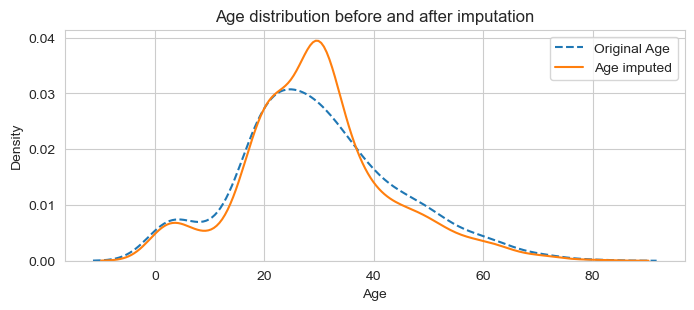

In [16]:
# Age imputation demonstration: fill Age with median by Title
age_med_by_title = df.groupby('Title')['Age'].median()
df['Age_imputed'] = df['Age']
missing_age = df['Age_imputed'].isnull().sum()
if missing_age > 0:
    df['Age_imputed'] = df.apply(lambda row: age_med_by_title[row['Title']] if pd.isnull(row['Age']) else row['Age'], axis=1)
    print(f'Filled {missing_age} missing Age values with median by Title')

# Compare distribution
plt.figure(figsize=(8,3))
sns.kdeplot(df['Age'].dropna(), label='Original Age', linestyle='--')
sns.kdeplot(df['Age_imputed'], label='Age imputed')
plt.legend()
plt.title('Age distribution before and after imputation')
plt.show()

In [17]:
# Example: Preparing a small dataframe for modeling (encoding categorical features)
model_df = df[['Survived','Pclass','Sex','Age_imputed','Fare','Embarked','FamilySize','Title']].copy()
model_df = pd.get_dummies(model_df, columns=['Sex','Embarked','Title'], drop_first=True)
print('Prepared dataset for modeling with shape:', model_df.shape)
display(model_df.head())

Prepared dataset for modeling with shape: (891, 12)


,Survived,Pclass,Age_imputed,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,7.2500,2,True,False,True,False,True,False,False
1,1,1,38.0,71.2833,2,False,False,False,False,False,True,False
2,1,3,26.0,7.9250,1,False,False,True,True,False,False,False
3,1,1,35.0,53.1000,2,False,False,True,False,False,True,False
4,0,3,35.0,8.0500,1,True,False,True,False,True,False,False


## Summary of findings & next steps

- **Missing values:** Age and Cabin have the most missing values. Age can be imputed (by Title or median); Cabin may be condensed to deck or use 'has_cabin' flag.
- **Key predictors of survival:** Sex (female higher), Pclass (lower class less survival), Fare (higher fares more likely to survive), Title (e.g., Mrs/Miss/Master), Age has a nuanced effect.
- **Feature engineering suggestions:** FamilySize, Title, HasCabin, Deck extracted from Cabin, Age bins, Fare bins.
- **Next steps:** Clean Cabin, impute Age, transform skewed Fare (log), scale features, then train & validate predictive models (logistic regression, random forest) and evaluate.
